In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style = "darkgrid")
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/final.csv")
df.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,x,y,z,subject,gesture_name
0,0,0,0,0.04,0.02,1.0,1,Lift
1,1,1,1,0.04,0.02,1.0,1,Lift
2,2,2,2,0.04,0.02,1.0,1,Lift
3,3,3,3,0.04,0.02,1.0,1,Lift
4,4,4,4,0.04,0.02,1.0,1,Lift


In [4]:
df.drop(columns = ["Unnamed: 0.2", "Unnamed: 0.1", "Unnamed: 0"], inplace = True)
df.head()

,x,y,z,subject,gesture_name
0,0.04,0.02,1.0,1,Lift
1,0.04,0.02,1.0,1,Lift
2,0.04,0.02,1.0,1,Lift
3,0.04,0.02,1.0,1,Lift
4,0.04,0.02,1.0,1,Lift


In [5]:
df.shape

(19814, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19814 entries, 0 to 19813
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   x             19814 non-null  float64
 1   y             19813 non-null  float64
 2   z             19812 non-null  float64
 3   subject       19814 non-null  int64  
 4   gesture_name  19814 non-null  object 
dtypes: float64(3), int64(1), object(1)
memory usage: 774.1+ KB


In [7]:
df["subject"] = df["subject"].astype("object")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19814 entries, 0 to 19813
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   x             19814 non-null  float64
 1   y             19813 non-null  float64
 2   z             19812 non-null  float64
 3   subject       19814 non-null  object 
 4   gesture_name  19814 non-null  object 
dtypes: float64(3), object(2)
memory usage: 774.1+ KB


In [8]:
df.describe()

,x,y,z
count,19814.000000,19813.000000,19812.000000
mean,0.041652,0.028014,0.957378
std,0.159490,0.193780,0.177860
min,-1.020000,-1.710000,-0.710000
25%,0.040000,0.010000,1.000000
50%,0.040000,0.030000,1.000000
75%,0.040000,0.050000,1.000000
max,1.070000,1.540000,1.820000


In [9]:
df["subject"].nunique()

6

In [10]:
df["subject"].value_counts()

subject
6    3631
3    3492
5    3469
4    3455
1    2947
2    2820
Name: count, dtype: int64

In [11]:
df["gesture_name"].nunique()

7

In [12]:
df["gesture_name"].value_counts()

gesture_name
Yaw Right     3153
Tilt Down     2895
Roll Right    2826
Roll Left     2806
Yaw Left      2800
Lift          2677
Tilt Up       2657
Name: count, dtype: int64

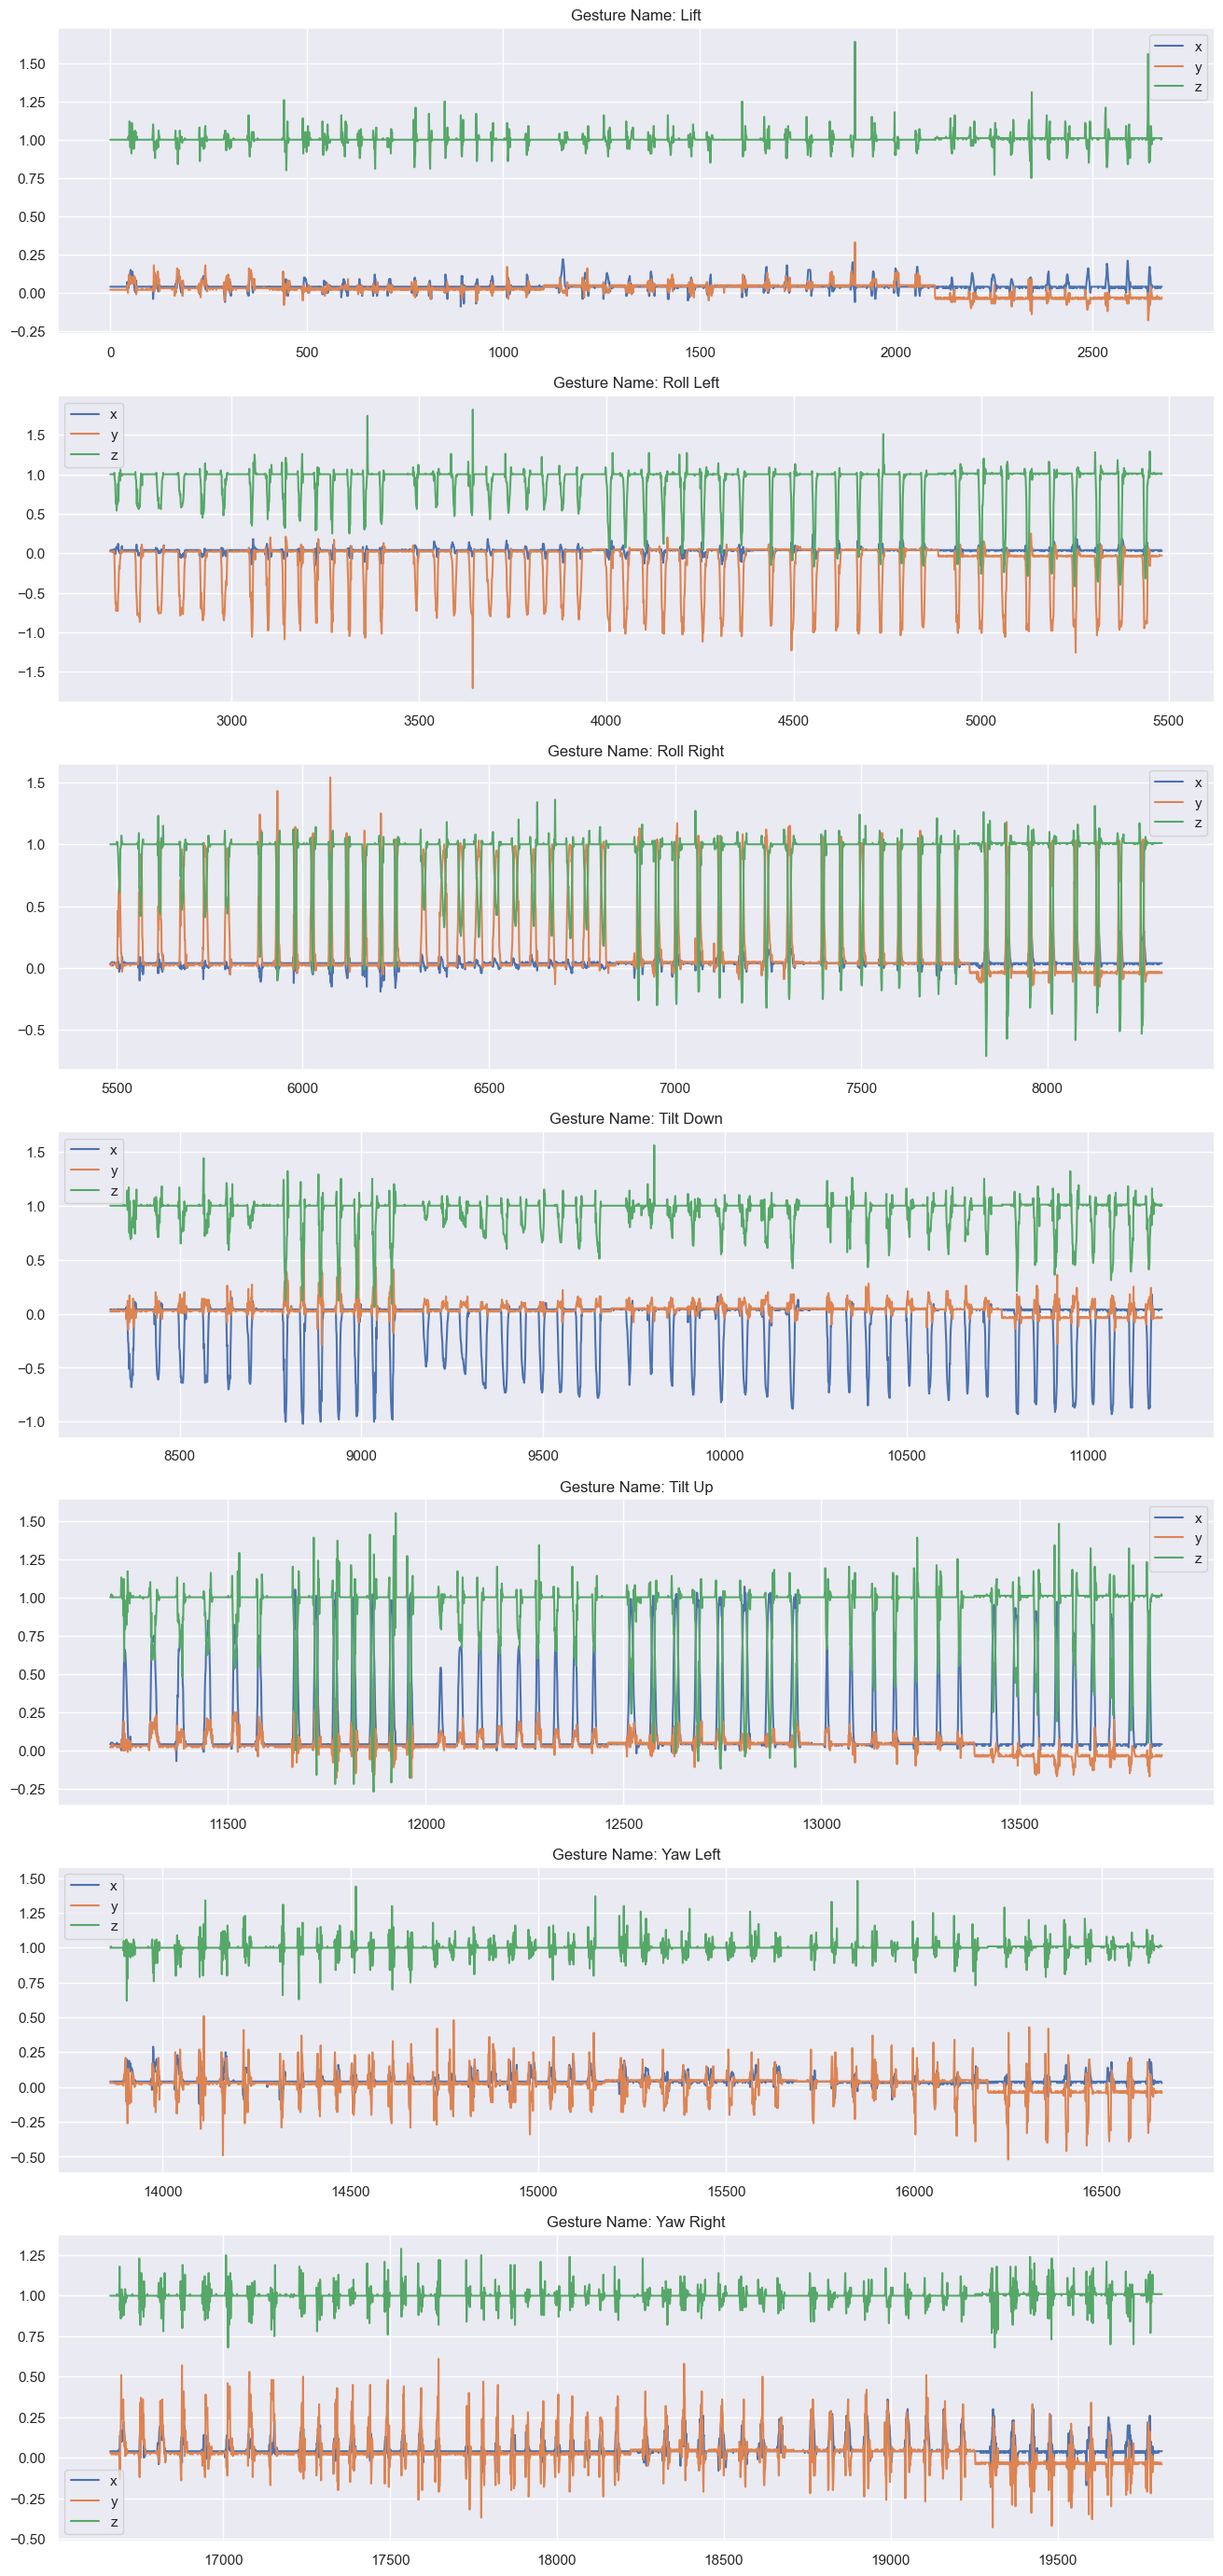

In [13]:
plt.figure(figsize = (16, 35))

plt.subplot(7, 1, 1)
plt.title("Gesture Name: Lift")
df[df["gesture_name"] == "Lift"]["x"].plot()
df[df["gesture_name"] == "Lift"]["y"].plot()
df[df["gesture_name"] == "Lift"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 2)
plt.title("Gesture Name: Roll Left")
df[df["gesture_name"] == "Roll Left"]["x"].plot()
df[df["gesture_name"] == "Roll Left"]["y"].plot()
df[df["gesture_name"] == "Roll Left"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 3)
plt.title("Gesture Name: Roll Right")
df[df["gesture_name"] == "Roll Right"]["x"].plot()
df[df["gesture_name"] == "Roll Right"]["y"].plot()
df[df["gesture_name"] == "Roll Right"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 4)
plt.title("Gesture Name: Tilt Down")
df[df["gesture_name"] == "Tilt Down"]["x"].plot()
df[df["gesture_name"] == "Tilt Down"]["y"].plot()
df[df["gesture_name"] == "Tilt Down"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 5)
plt.title("Gesture Name: Tilt Up")
df[df["gesture_name"] == "Tilt Up"]["x"].plot()
df[df["gesture_name"] == "Tilt Up"]["y"].plot()
df[df["gesture_name"] == "Tilt Up"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 6)
plt.title("Gesture Name: Yaw Left")
df[df["gesture_name"] == "Yaw Left"]["x"].plot()
df[df["gesture_name"] == "Yaw Left"]["y"].plot()
df[df["gesture_name"] == "Yaw Left"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 7)
plt.title("Gesture Name: Yaw Right")
df[df["gesture_name"] == "Yaw Right"]["x"].plot()
df[df["gesture_name"] == "Yaw Right"]["y"].plot()
df[df["gesture_name"] == "Yaw Right"]["z"].plot()
plt.legend()

plt.savefig("../artifacts/raw_sensor_data.png")
plt.show()

In [14]:
import plotly.graph_objects as go

fig = go.Figure(
    data = [
        go.Scatter3d(x = df[df["gesture_name"] == "Lift"]["x"], y = df[df["gesture_name"] == "Lift"]["y"], z = df[df["gesture_name"] == "Lift"]["z"], mode = "markers", marker = dict(color = "red"), name = "Lift"),
        go.Scatter3d(x = df[df["gesture_name"] == "Roll Left"]["x"], y = df[df["gesture_name"] == "Roll Left"]["y"], z = df[df["gesture_name"] == "Roll Left"]["z"], mode = "markers", marker = dict(color = "yellow"), name = "Roll Left"),
        go.Scatter3d(x = df[df["gesture_name"] == "Roll Right"]["x"], y = df[df["gesture_name"] == "Roll Right"]["y"], z = df[df["gesture_name"] == "Roll Right"]["z"], mode = "markers", marker = dict(color = "green"), name = "Roll Right"),
        go.Scatter3d(x = df[df["gesture_name"] == "Tilt Down"]["x"], y = df[df["gesture_name"] == "Tilt Down"]["y"], z = df[df["gesture_name"] == "Tilt Down"]["z"], mode = "markers", marker = dict(color = "blue"), name = "Tilt Up"),
        go.Scatter3d(x = df[df["gesture_name"] == "Tilt Up"]["x"], y = df[df["gesture_name"] == "Tilt Up"]["y"], z = df[df["gesture_name"] == "Tilt Up"]["z"], mode = "markers", marker = dict(color = "orange"), name = "Tilt Down"),
        go.Scatter3d(x = df[df["gesture_name"] == "Yaw Left"]["x"], y = df[df["gesture_name"] == "Yaw Left"]["y"], z = df[df["gesture_name"] == "Yaw Left"]["z"], mode = "markers", marker = dict(color = "cyan"), name = "Yaw Left"),
        go.Scatter3d(x = df[df["gesture_name"] == "Yaw Right"]["x"], y = df[df["gesture_name"] == "Yaw Right"]["y"], z = df[df["gesture_name"] == "Yaw Right"]["z"], mode = "markers", marker = dict(color = "grey"), name = "Yaw Right")
    ]
)

fig.update_layout(width = 1000,  height = 600)
fig.show()

<Axes: >

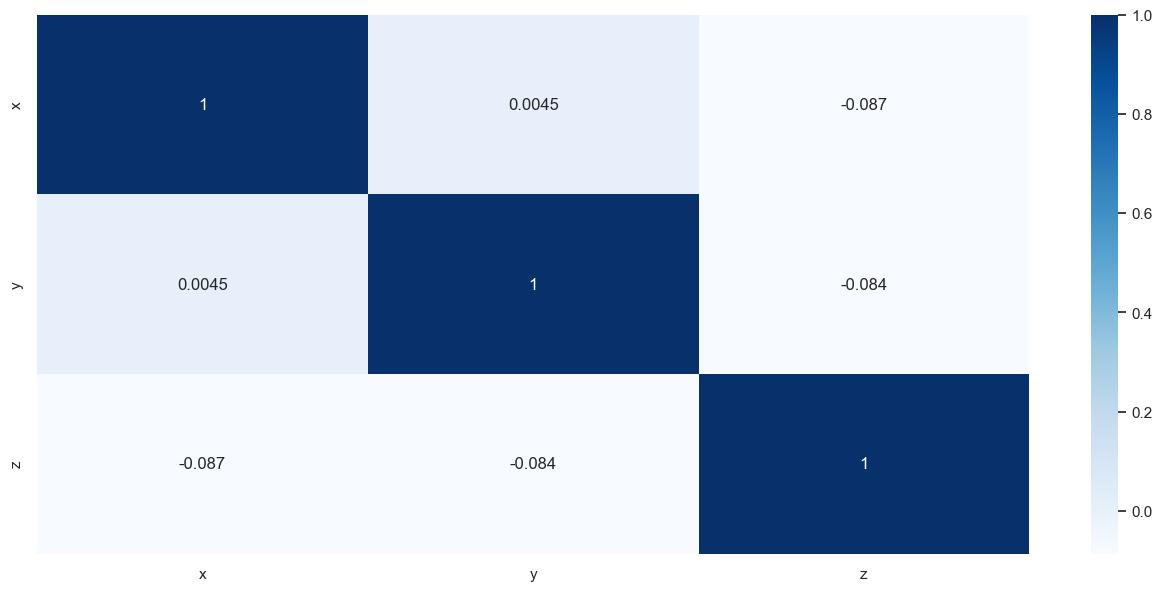

In [15]:
plt.figure(figsize = (16, 7))
sns.heatmap(df[["x", "y", "z"]].corr(), annot = True, cmap = "Blues")

<Axes: xlabel='z'>

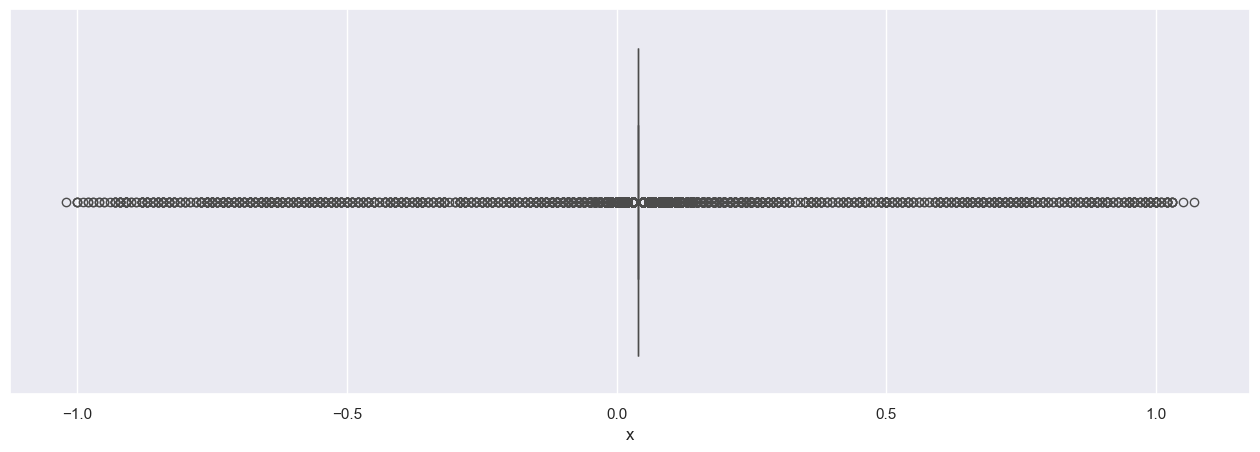

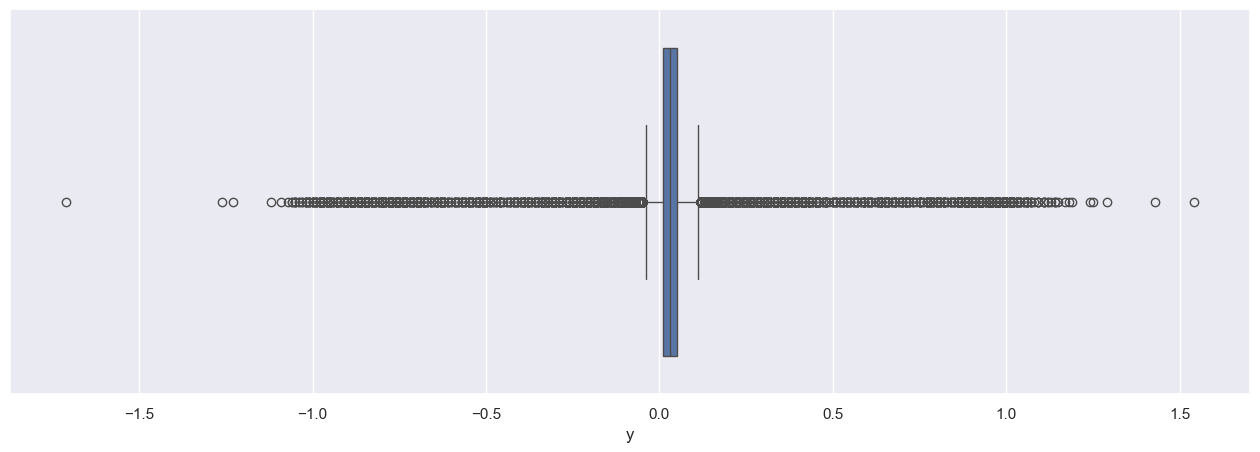

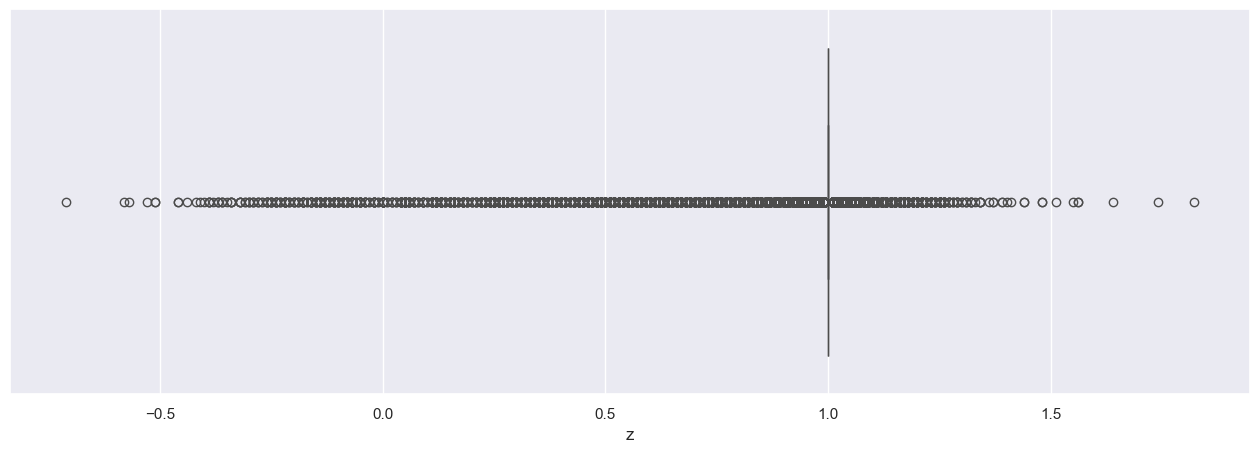

In [16]:
plt.figure(figsize = (16, 5))
sns.boxplot(data = df, x = df["x"])

plt.figure(figsize = (16, 5))
sns.boxplot(data = df, x = df["y"])

plt.figure(figsize = (16, 5))
sns.boxplot(data = df, x = df["z"])

In [17]:
# adjust "y" values for subject 6
df.loc[df["subject"] == 6, "y"] += 0.08

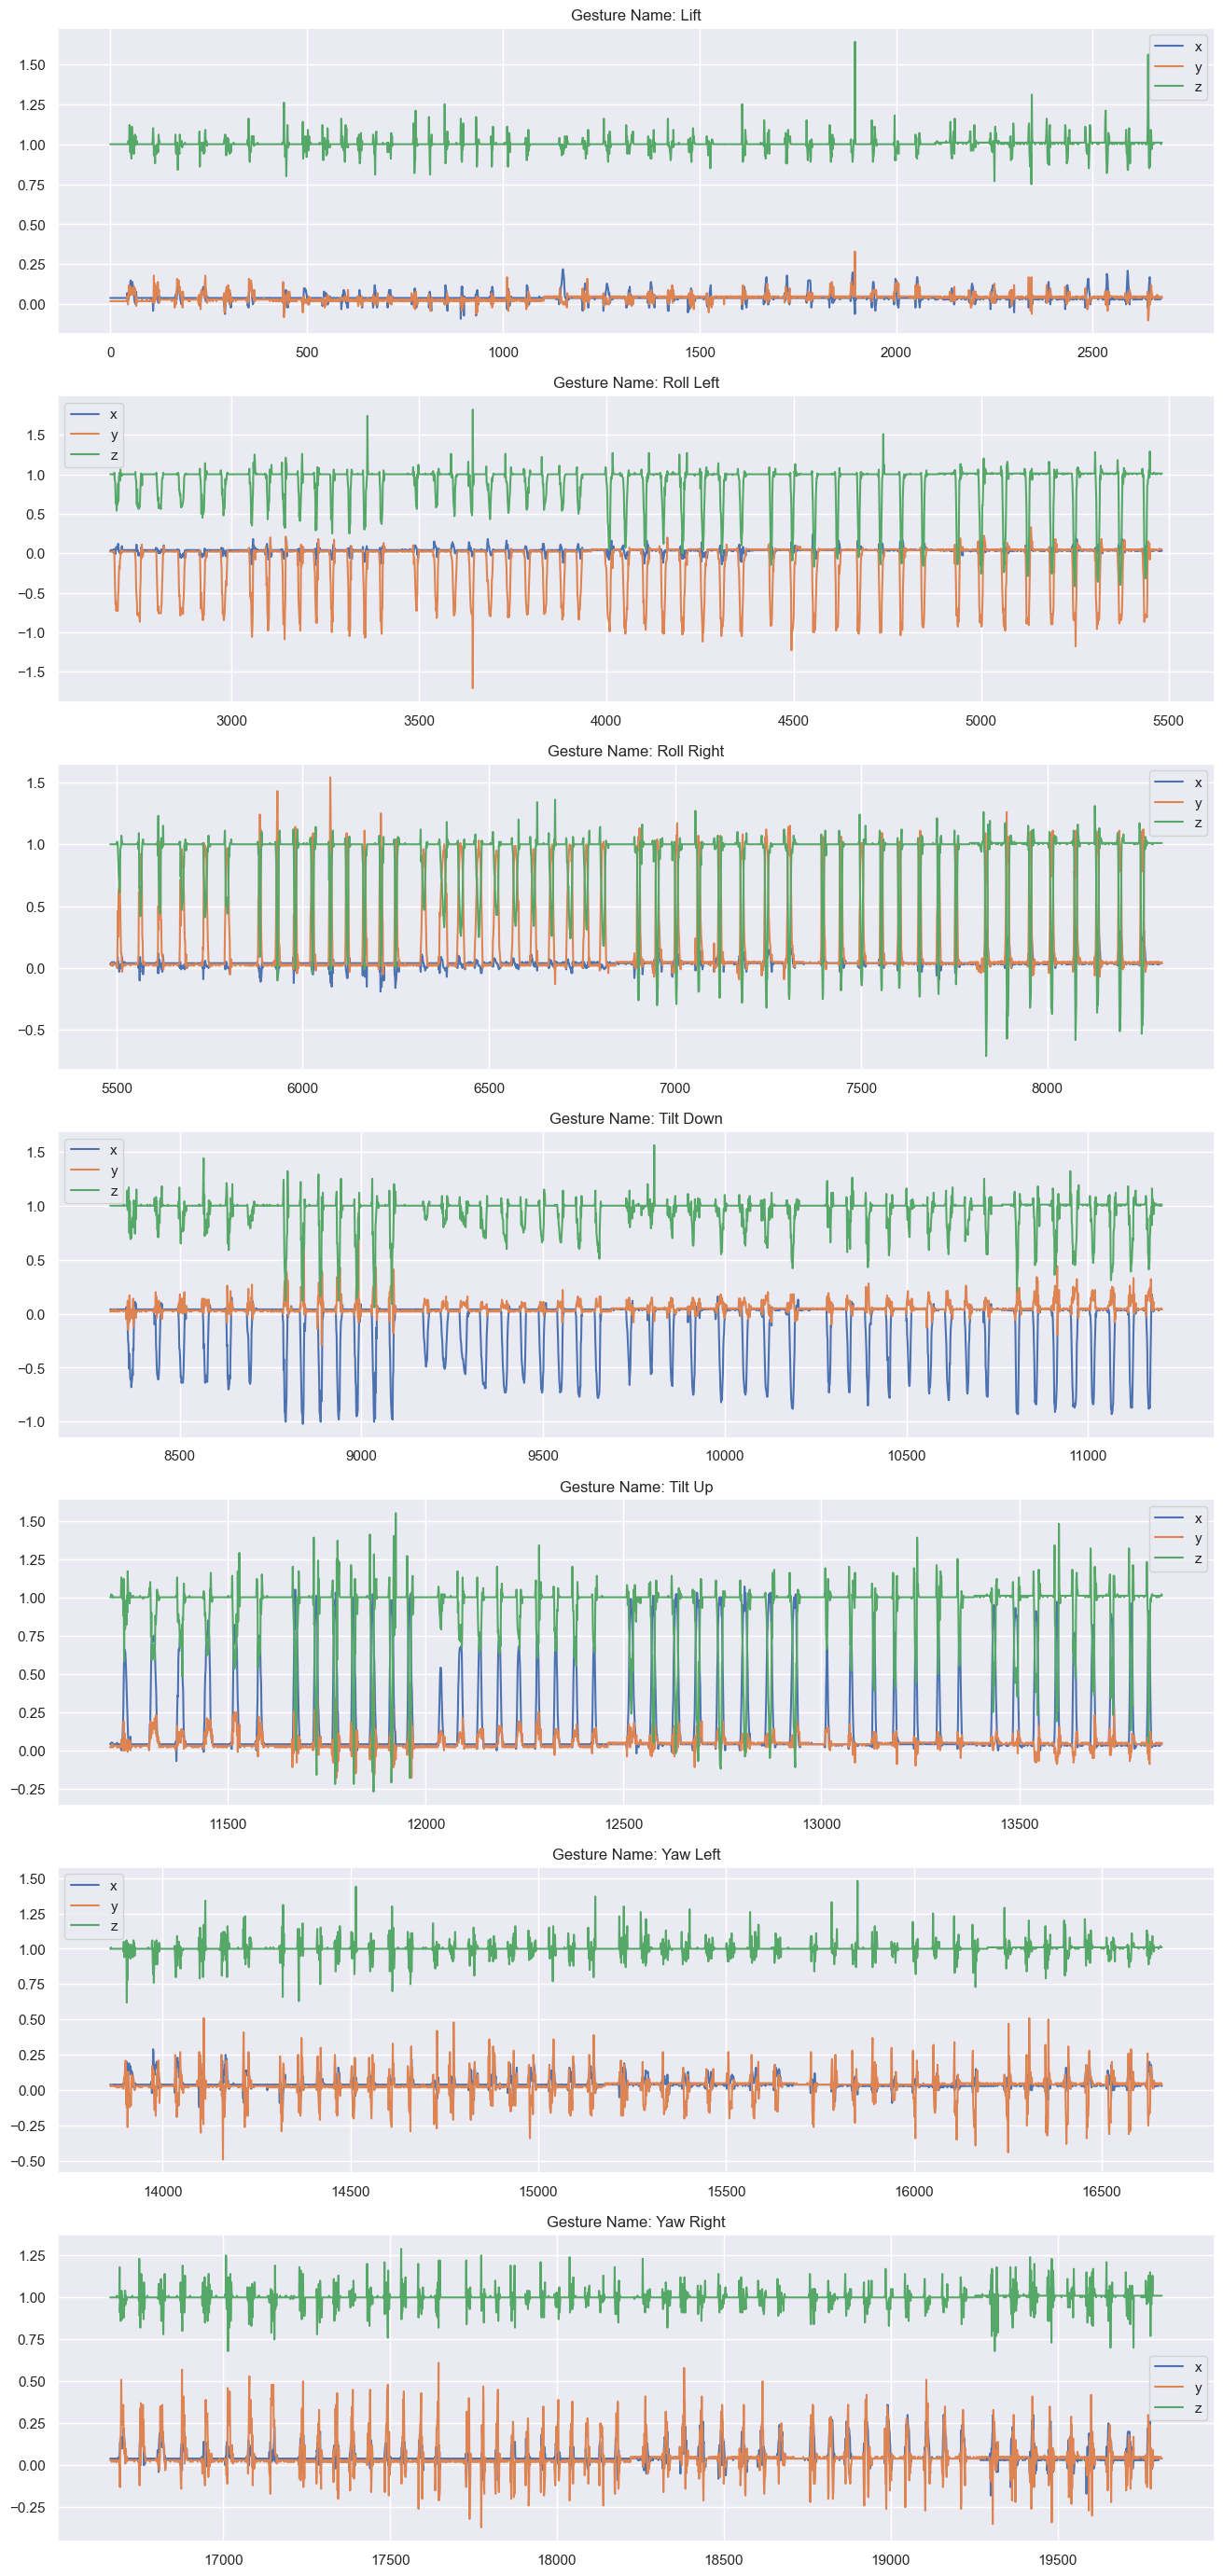

In [18]:
plt.figure(figsize = (16, 35))

plt.subplot(7, 1, 1)
plt.title("Gesture Name: Lift")
df[df["gesture_name"] == "Lift"]["x"].plot()
df[df["gesture_name"] == "Lift"]["y"].plot()
df[df["gesture_name"] == "Lift"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 2)
plt.title("Gesture Name: Roll Left")
df[df["gesture_name"] == "Roll Left"]["x"].plot()
df[df["gesture_name"] == "Roll Left"]["y"].plot()
df[df["gesture_name"] == "Roll Left"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 3)
plt.title("Gesture Name: Roll Right")
df[df["gesture_name"] == "Roll Right"]["x"].plot()
df[df["gesture_name"] == "Roll Right"]["y"].plot()
df[df["gesture_name"] == "Roll Right"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 4)
plt.title("Gesture Name: Tilt Down")
df[df["gesture_name"] == "Tilt Down"]["x"].plot()
df[df["gesture_name"] == "Tilt Down"]["y"].plot()
df[df["gesture_name"] == "Tilt Down"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 5)
plt.title("Gesture Name: Tilt Up")
df[df["gesture_name"] == "Tilt Up"]["x"].plot()
df[df["gesture_name"] == "Tilt Up"]["y"].plot()
df[df["gesture_name"] == "Tilt Up"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 6)
plt.title("Gesture Name: Yaw Left")
df[df["gesture_name"] == "Yaw Left"]["x"].plot()
df[df["gesture_name"] == "Yaw Left"]["y"].plot()
df[df["gesture_name"] == "Yaw Left"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 7)
plt.title("Gesture Name: Yaw Right")
df[df["gesture_name"] == "Yaw Right"]["x"].plot()
df[df["gesture_name"] == "Yaw Right"]["y"].plot()
df[df["gesture_name"] == "Yaw Right"]["z"].plot()
plt.legend()

plt.savefig("../artifacts/corrected_sensor_data.png")
plt.show()

In [19]:
q1 = df["x"].quantile(0.05)
q3 = df["x"].quantile(0.95)
iqr = q3 - q1

lower_bound = q1 - (iqr * 1.5)
upper_bound = q3 + (iqr * 1.5)
outliers = ((df["x"] < lower_bound) | (df["x"] > upper_bound))

print(df.shape)
df = df[~ outliers]
print(df.shape)

(19814, 5)
(18897, 5)


In [20]:
q1 = df["y"].quantile(0.05)
q3 = df["y"].quantile(0.95)
iqr = q3 - q1

lower_bound = q1 - (iqr * 1.5)
upper_bound = q3 + (iqr * 1.5)
outliers = ((df["y"] < lower_bound) | (df["y"] > upper_bound))

print(df.shape)
df = df[~ outliers]
print(df.shape)

(18897, 5)
(18144, 5)


In [21]:
q1 = df["z"].quantile(0.05)
q3 = df["z"].quantile(0.95)
iqr = q3 - q1

lower_bound = q1 - (iqr * 1.5)
upper_bound = q3 + (iqr * 1.5)
outliers = ((df["z"] < lower_bound) | (df["z"] > upper_bound))

print(df.shape)
df = df[~ outliers]
print(df.shape)

(18144, 5)
(18008, 5)


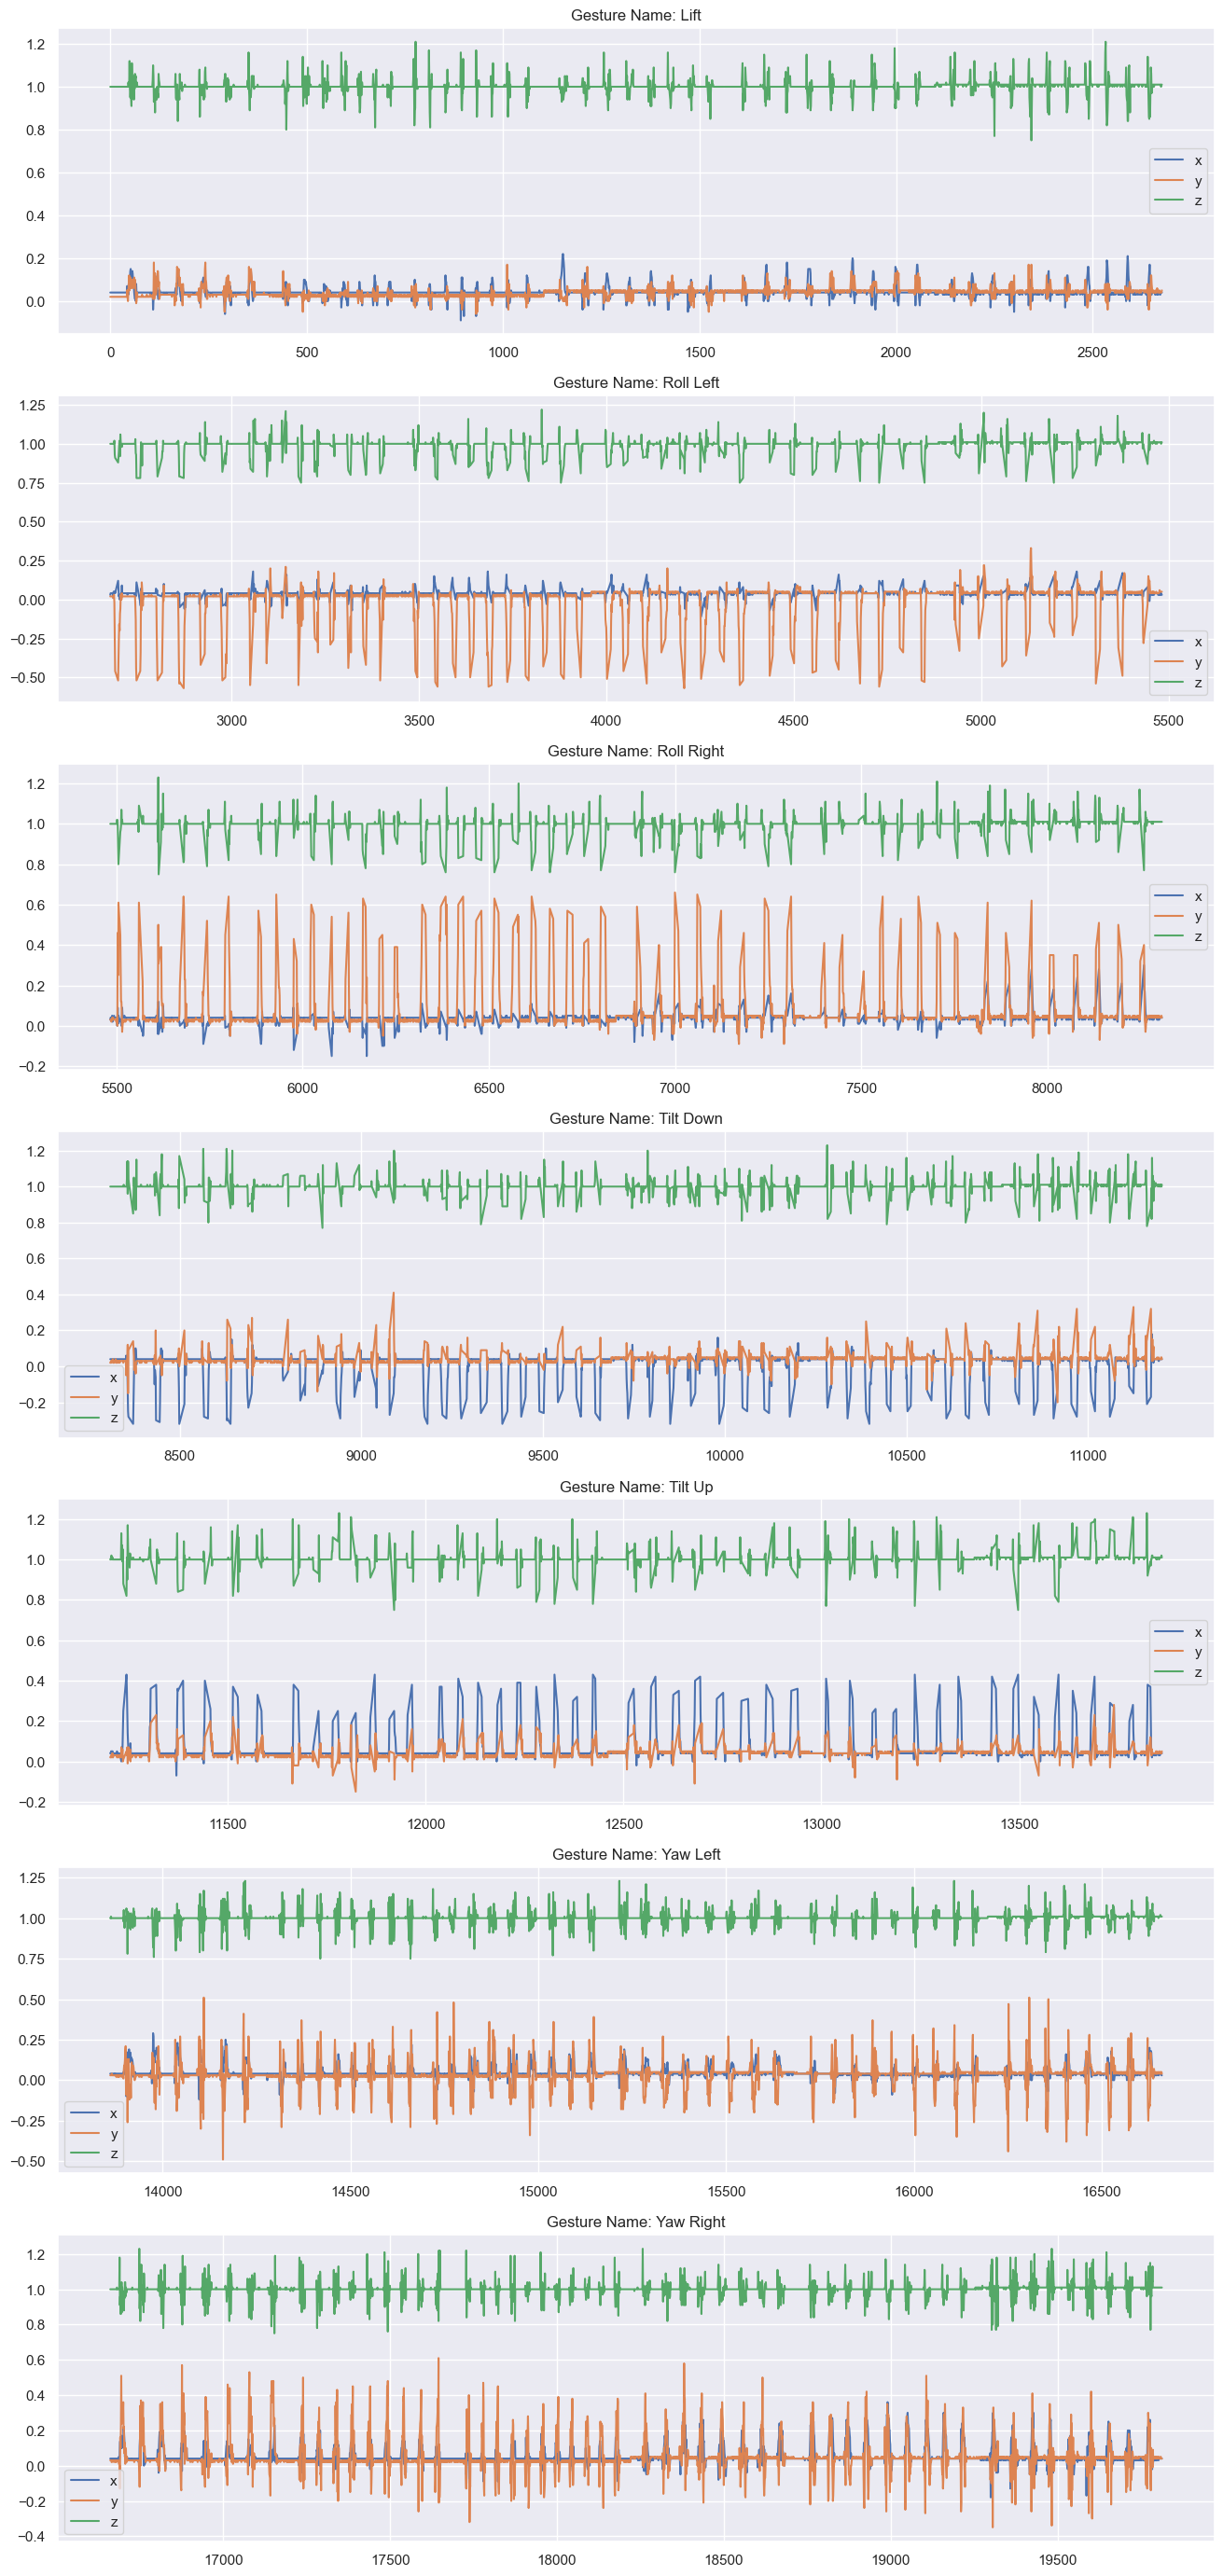

In [22]:
plt.figure(figsize = (16, 35))

plt.subplot(7, 1, 1)
plt.title("Gesture Name: Lift")
df[df["gesture_name"] == "Lift"]["x"].plot()
df[df["gesture_name"] == "Lift"]["y"].plot()
df[df["gesture_name"] == "Lift"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 2)
plt.title("Gesture Name: Roll Left")
df[df["gesture_name"] == "Roll Left"]["x"].plot()
df[df["gesture_name"] == "Roll Left"]["y"].plot()
df[df["gesture_name"] == "Roll Left"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 3)
plt.title("Gesture Name: Roll Right")
df[df["gesture_name"] == "Roll Right"]["x"].plot()
df[df["gesture_name"] == "Roll Right"]["y"].plot()
df[df["gesture_name"] == "Roll Right"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 4)
plt.title("Gesture Name: Tilt Down")
df[df["gesture_name"] == "Tilt Down"]["x"].plot()
df[df["gesture_name"] == "Tilt Down"]["y"].plot()
df[df["gesture_name"] == "Tilt Down"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 5)
plt.title("Gesture Name: Tilt Up")
df[df["gesture_name"] == "Tilt Up"]["x"].plot()
df[df["gesture_name"] == "Tilt Up"]["y"].plot()
df[df["gesture_name"] == "Tilt Up"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 6)
plt.title("Gesture Name: Yaw Left")
df[df["gesture_name"] == "Yaw Left"]["x"].plot()
df[df["gesture_name"] == "Yaw Left"]["y"].plot()
df[df["gesture_name"] == "Yaw Left"]["z"].plot()
plt.legend()

plt.subplot(7, 1, 7)
plt.title("Gesture Name: Yaw Right")
df[df["gesture_name"] == "Yaw Right"]["x"].plot()
df[df["gesture_name"] == "Yaw Right"]["y"].plot()
df[df["gesture_name"] == "Yaw Right"]["z"].plot()
plt.legend()

plt.savefig("../artifacts/winsorized_sensor_data.png")
plt.show()

In [23]:
import plotly.graph_objects as go

fig = go.Figure(
    data = [
        go.Scatter3d(x = df[df["gesture_name"] == "Lift"]["x"], y = df[df["gesture_name"] == "Lift"]["y"], z = df[df["gesture_name"] == "Lift"]["z"], mode = "markers", marker = dict(color = "red"), name = "Lift"),
        go.Scatter3d(x = df[df["gesture_name"] == "Roll Left"]["x"], y = df[df["gesture_name"] == "Roll Left"]["y"], z = df[df["gesture_name"] == "Roll Left"]["z"], mode = "markers", marker = dict(color = "yellow"), name = "Roll Left"),
        go.Scatter3d(x = df[df["gesture_name"] == "Roll Right"]["x"], y = df[df["gesture_name"] == "Roll Right"]["y"], z = df[df["gesture_name"] == "Roll Right"]["z"], mode = "markers", marker = dict(color = "green"), name = "Roll Right"),
        go.Scatter3d(x = df[df["gesture_name"] == "Tilt Down"]["x"], y = df[df["gesture_name"] == "Tilt Down"]["y"], z = df[df["gesture_name"] == "Tilt Down"]["z"], mode = "markers", marker = dict(color = "blue"), name = "Tilt Up"),
        go.Scatter3d(x = df[df["gesture_name"] == "Tilt Up"]["x"], y = df[df["gesture_name"] == "Tilt Up"]["y"], z = df[df["gesture_name"] == "Tilt Up"]["z"], mode = "markers", marker = dict(color = "orange"), name = "Tilt Down"),
        go.Scatter3d(x = df[df["gesture_name"] == "Yaw Left"]["x"], y = df[df["gesture_name"] == "Yaw Left"]["y"], z = df[df["gesture_name"] == "Yaw Left"]["z"], mode = "markers", marker = dict(color = "cyan"), name = "Yaw Left"),
        go.Scatter3d(x = df[df["gesture_name"] == "Yaw Right"]["x"], y = df[df["gesture_name"] == "Yaw Right"]["y"], z = df[df["gesture_name"] == "Yaw Right"]["z"], mode = "markers", marker = dict(color = "grey"), name = "Yaw Right")
    ]
)

fig.update_layout(width = 1000,  height = 600)
fig.show()

In [24]:
df.sample(10)

,x,y,z,subject,gesture_name
13916,0.11,-0.11,1.03,1,Yaw Left
3577,0.04,0.03,1.00,3,Roll Left
12616,0.04,0.05,1.00,4,Tilt Up
14628,0.04,0.02,1.00,2,Yaw Left
9720,0.04,0.05,1.00,4,Tilt Down
7168,-0.01,-0.04,1.10,4,Roll Right
127,0.04,0.03,1.00,1,Lift
15680,0.04,0.05,1.00,4,Yaw Left
5236,0.04,0.05,1.01,6,Roll Left
207,0.04,0.03,1.00,1,Lift


In [25]:
df.drop(columns = ["subject"], inplace = True)
df.sample(10, random_state = 42)

,x,y,z,gesture_name
10178,-0.14,0.06,0.93,Tilt Down
8585,0.05,0.02,1.03,Tilt Down
451,-0.01,0.05,1.12,Lift
6014,0.04,0.03,1.00,Roll Right
15342,0.06,-0.05,1.00,Yaw Left
2137,0.05,0.08,1.04,Lift
2683,0.04,0.02,1.00,Roll Left
15998,0.00,0.28,1.02,Yaw Left
15404,0.04,0.05,1.01,Yaw Left
13447,0.00,0.08,1.02,Tilt Up


In [26]:
# label encoding gesture_name
df["gesture_name"].unique()

array(['Lift', 'Roll Left', 'Roll Right', 'Tilt Down', 'Tilt Up',
       'Yaw Left', 'Yaw Right'], dtype=object)

In [27]:
from sklearn.preprocessing import LabelEncoder

data = ["Lift", "Roll Left", "Roll Right", "Tilt Down", "Tilt Up", "Yaw Left", "yaw Right"]

label_encoder = LabelEncoder()
label_encoder.fit(df["gesture_name"])
df["gesture_name"] = label_encoder.transform(df["gesture_name"])

df.sample(10, random_state = 42)

,x,y,z,gesture_name
10178,-0.14,0.06,0.93,3
8585,0.05,0.02,1.03,3
451,-0.01,0.05,1.12,0
6014,0.04,0.03,1.00,2
15342,0.06,-0.05,1.00,5
2137,0.05,0.08,1.04,0
2683,0.04,0.02,1.00,1
15998,0.00,0.28,1.02,5
15404,0.04,0.05,1.01,5
13447,0.00,0.08,1.02,4


In [28]:
# separating features and label
x = df.drop(columns = ["gesture_name"])
x.sample(10)

,x,y,z
14509,0.01,-0.20,0.99
6932,0.04,0.05,1.00
7421,0.04,0.04,1.00
17874,0.14,-0.01,0.82
512,0.04,0.03,1.00
9076,-0.00,0.15,1.00
3552,0.01,-0.09,0.99
18460,0.04,0.04,1.00
13835,0.02,0.06,1.02
19040,0.04,0.04,1.00


In [29]:
y = df["gesture_name"]
y.sample(10)

727      0
19359    6
7578     2
16552    5
957      0
11759    4
3703     1
15058    5
9221     3
7519     2
Name: gesture_name, dtype: int64